In [4]:
# Strike Squad - HDFCBANK Data Acquisition
# This Notebook will fetch HDFC stock data, check it out, and make sure 
# everything looks good before we dive into the heavy analysis.

# WHAT THIS NOTEBOOK DOES:
#1. Fetches 2 years of HDFCBANK stock data from Yahoo Finance
#2. Downloads RBI risk-free rates (or uses reasonable fallback)
#3. Gets dividend information for HDFC
#4. Validates everything to make sure data quality is solid
#5. Saves cleaned data for the rest of our analysis

In [5]:
#Setup & Imports
# Core libraries
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Data fetching
import yfinance as yf
import requests
from io import StringIO

# Visualization (for quick checks)
import matplotlib.pyplot as plt
import seaborn as sns

# Config handling
import yaml
import os
from pathlib import Path

# Progress tracking
from tqdm import tqdm

print("✅ All libraries imported successfully!")
print()

✅ All libraries imported successfully!



In [6]:
#Loading Configuration

print("Loading project configuration...\n")

# Path to configuration file
config_path = Path("../config/config.yaml")

if not config_path.exists():
    raise FileNotFoundError(
        "Configuration file 'config.yaml' not found. "
        "Please ensure it is located in the /config directory."
    )

# Load configuration settings
with open(config_path, "r") as f:
    config = yaml.safe_load(f)

# Extract commonly used parameters
TICKER = config["company"]["ticker_yahoo"]
START_DATE = config["data"]["start_date"]
END_DATE = config["data"]["end_date"]

TEAM_NAME = config["project"]["team"]
PROJECT_AUTHOR = config["project"]["created_by"]

print("Configuration loaded successfully.")
print(f"Team Name      : {TEAM_NAME}")
print(f"Analyzing       : {config['company']['name']}")
print(f"Ticker Symbol   : {TICKER}")
print(f"Date Range      : {START_DATE} to {END_DATE}")
print(f"Prepared By     : {PROJECT_AUTHOR}\n")


Loading project configuration...

Configuration loaded successfully.
Team Name      : Strike Squad
Analyzing       : HDFC Bank Ltd
Ticker Symbol   : HDFCBANK.NS
Date Range      : 2023-11-01 to 2025-11-21
Prepared By     : Shubhra Arora



In [16]:
# Load raw HDFCBANK stock data

stock_file = Path("../data/raw/hdfc_stock_raw.csv")

if not stock_file.exists():
    raise FileNotFoundError(f"Raw stock data not found at: {stock_file}")

stock_raw = pd.read_csv(stock_file)
print("Raw stock data loaded.")
print(stock_raw.head())


Raw stock data loaded.
                        Date        Open        High         Low       Close  \
0  2023-11-01 00:00:00+05:30  711.656142  719.053741  711.656142  717.618042   
1  2023-11-02 00:00:00+05:30  722.728353  725.405125  714.041024  718.713196   
2  2023-11-03 00:00:00+05:30  724.188348  725.843092  721.097906  722.119934   
3  2023-11-06 00:00:00+05:30  729.055268  729.055268  721.754981  727.351868   
4  2023-11-07 00:00:00+05:30  727.108493  727.108493  718.932149  723.823364   

     Volume  
0  33877466  
1  45225154  
2  18095340  
3  25593730  
4  41952848  


In [7]:
# CELL 1: Download and Save HDFCBANK Daily Stock Data
# This cell fetches historical HDFCBANK prices directly from Yahoo Finance
# and stores them as a raw CSV file for subsequent processing.

print("Downloading HDFCBANK daily stock data...")

ticker_obj = yf.Ticker("HDFCBANK.NS")

# Download data over the configured date range
raw_stock_df = ticker_obj.history(
    start=START_DATE,
    end=END_DATE,
    actions=False
)

if raw_stock_df.empty:
    raise ValueError("No stock data returned. Please check the date range or ticker symbol.")

# Ensure directory exists
Path("../data/raw").mkdir(parents=True, exist_ok=True)

# Save file
raw_stock_path = "../data/raw/hdfc_stock_raw.csv"
raw_stock_df.to_csv(raw_stock_path)

print(f"Raw stock data saved to: {raw_stock_path}")
print(f"Total records downloaded: {len(raw_stock_df)}\n")


Raw stock data saved to: ../data/raw/hdfc_stock_raw.csv
Total records downloaded: 508



In [8]:
# CELL 2: Load HDFCBANK Daily Stock Data
# This version supports CSV files that contain only OHLCV data.
# Since the file does not include an adjusted close column,
# we will use the Close column as the working price series.

from pathlib import Path

print("Loading HDFCBANK daily stock data...\n")

try:
    stock_file_path = Path("../data/raw/hdfc_stock_raw.csv")
    hdfc_stock_raw = pd.read_csv(
        stock_file_path,
        parse_dates=["Date"],
        index_col="Date"
    )

    print("File successfully loaded.")
    print(f"Total records: {len(hdfc_stock_raw)}\n")

    # Expected minimum columns: OHLCV
    required_cols = ["Open", "High", "Low", "Close", "Volume"]
    missing = [c for c in required_cols if c not in hdfc_stock_raw.columns]

    if missing:
        raise KeyError(f"Missing required columns: {missing}")

    # Convert numeric columns safely
    for col in required_cols:
        hdfc_stock_raw[col] = pd.to_numeric(hdfc_stock_raw[col], errors="coerce")

    # Since no adjusted close exists, use Close as proxy
    hdfc_stock_raw["Adj Close"] = hdfc_stock_raw["Close"]
    print("Adjusted Close column not found — using Close as substitute.\n")

    # Summary
    print("Dataset Overview:")
    print(f" • First record : {hdfc_stock_raw.index.min().strftime('%Y-%m-%d')}")
    print(f" • Last record  : {hdfc_stock_raw.index.max().strftime('%Y-%m-%d')}")

    min_close = float(hdfc_stock_raw["Close"].min())
    max_close = float(hdfc_stock_raw["Close"].max())
    print(f" • Price range  : ₹{min_close:.2f} to ₹{max_close:.2f}\n")

except Exception as error:
    print("There was an issue loading the stock data.")
    print("Error details:", error)


Loading HDFCBANK daily stock data...

File successfully loaded.
Total records: 508

Adjusted Close column not found — using Close as substitute.

Dataset Overview:
 • First record : 2023-11-01
 • Last record  : 2025-11-20
 • Price range  : ₹673.60 to ₹1012.90



In [9]:
# CELL 3: Data Quality Checks
# Purpose:
#     Evaluate the integrity of the downloaded HDFCBANK data.
#     Checks include:
#       • Missing values
#       • Unexpected price jumps
#       • Basic structural validation
#     Ensuring data reliability is essential before any
#     pricing models or backtesting are performed.

# Check for missing values
missing_counts = hdfc_stock_raw.isnull().sum()

if missing_counts.sum() > 0:
    print("Missing Data Detected:")
    print(missing_counts[missing_counts > 0])
    print("\nThese will be handled appropriately in preprocessing.")
else:
    print("No missing values found in the dataset.")
print()


# Check for extreme daily price movements
print("Evaluating for unusual daily price changes...")

# Compute daily percentage change using adjusted closing price
hdfc_stock_raw["daily_return"] = hdfc_stock_raw["Adj Close"].pct_change()

# Define threshold for potential anomalies (e.g., >15% change)
anomaly_threshold = 0.15
extreme_days = hdfc_stock_raw[abs(hdfc_stock_raw["daily_return"]) > anomaly_threshold]

if len(extreme_days) > 0:
    print(f"Identified {len(extreme_days)} days with movements exceeding ±15%:")
    display(extreme_days[["Close", "Adj Close", "daily_return"]])
    print("\nThese may correspond to dividends, corporate actions, or data errors.")
else:
    print("No extreme price movements detected.")
print()

# Structural check summary
print("Dataset shape:", hdfc_stock_raw.shape)
print("Columns available:", list(hdfc_stock_raw.columns))
print()

print("Data quality checks completed.\n")


No missing values found in the dataset.

Evaluating for unusual daily price changes...
No extreme price movements detected.

Dataset shape: (508, 7)
Columns available: ['Open', 'High', 'Low', 'Close', 'Volume', 'Adj Close', 'daily_return']

Data quality checks completed.



In [10]:
# CELL 4: Calculate Returns and Volatility
# This step prepares the processed dataset required for option pricing
# and the backtest. It computes log returns and realized volatility.

print("Calculating log returns and volatility measures...\n")

# Prepare dataframe for processed data
hdfc_processed = pd.DataFrame()
hdfc_processed["date"] = hdfc_stock_raw.index
hdfc_processed["close"] = hdfc_stock_raw["Close"].values
hdfc_processed["adj_close"] = hdfc_stock_raw["Adj Close"].values
hdfc_processed["high"] = hdfc_stock_raw["High"].values
hdfc_processed["low"] = hdfc_stock_raw["Low"].values
hdfc_processed["volume"] = hdfc_stock_raw["Volume"].values

# Log returns (based on adjusted closing price)
hdfc_processed["log_return"] = np.log(
    hdfc_processed["adj_close"] / hdfc_processed["adj_close"].shift(1)
)

# Rolling realized volatility (using window defined in config)
vol_window = config["pricing"]["volatility_window_days"]
hdfc_processed["realized_vol_30d"] = (
    hdfc_processed["log_return"].rolling(window=vol_window).std()
)

# Annualize volatility using sqrt(252)
hdfc_processed["realized_vol_annual"] = (
    hdfc_processed["realized_vol_30d"] * np.sqrt(252)
)

print("Returns and volatility calculations completed.\n")

# Summary statistics for annualized volatility
avg_vol = hdfc_processed["realized_vol_annual"].mean()
min_vol = hdfc_processed["realized_vol_annual"].min()
max_vol = hdfc_processed["realized_vol_annual"].max()

print("HDFCBANK Annualized Volatility Summary:")
print(f"Average volatility : {avg_vol:.2%}")
print(f"Minimum volatility : {min_vol:.2%}")
print(f"Maximum volatility : {max_vol:.2%}\n")

print(
    "These volatility estimates will serve as inputs to the Black-Scholes model "
    "and as the sigma parameter in the binomial pricing model.\n"
)


Calculating log returns and volatility measures...

Returns and volatility calculations completed.

HDFCBANK Annualized Volatility Summary:
Average volatility : 18.79%
Minimum volatility : 9.08%
Maximum volatility : 33.45%

These volatility estimates will serve as inputs to the Black-Scholes model and as the sigma parameter in the binomial pricing model.



Generating stock price and volatility visualizations...



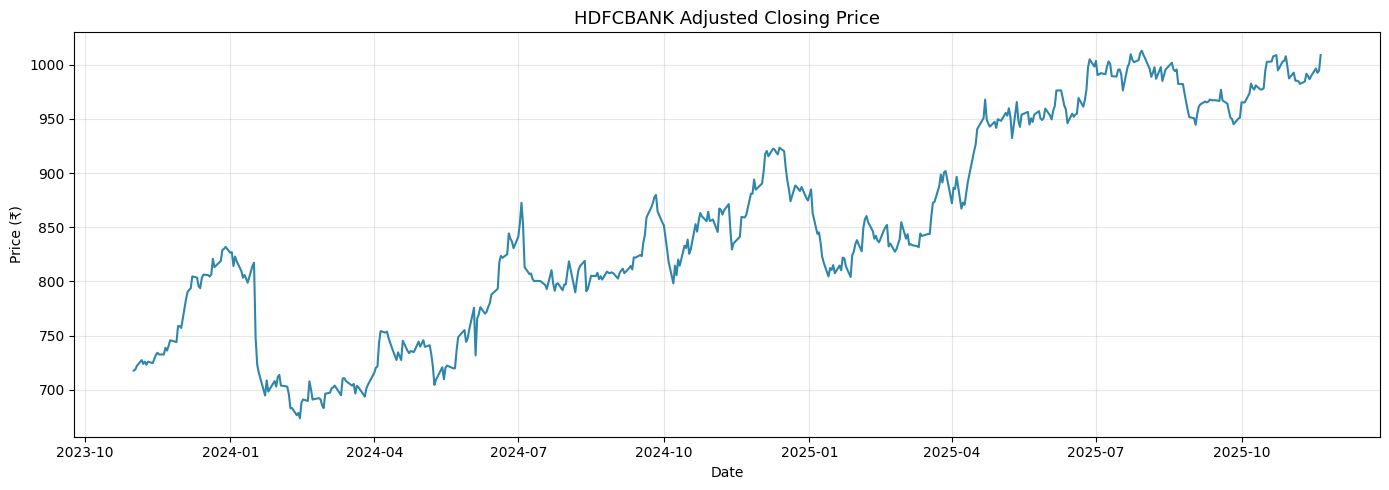

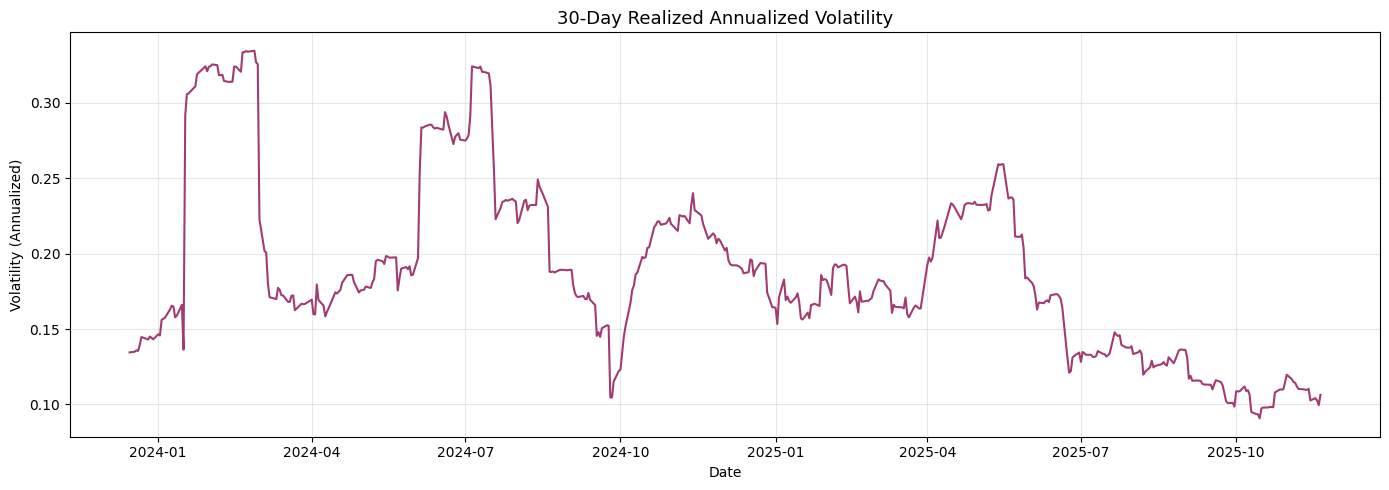

Visualizations generated successfully.



In [11]:
# CELL 5: Basic Visualizations
# This cell provides visual checks for HDFCBANK's historical price trend
# and its realized annualized volatility. These plots help confirm that
# the processed data behaves as expected before it is used in pricing
# models and backtesting.

print("Generating stock price and volatility visualizations...\n")

plt.figure(figsize=(14, 5))
plt.plot(hdfc_processed["date"], hdfc_processed["adj_close"], color="#2E86AB")
plt.title("HDFCBANK Adjusted Closing Price", fontsize=13)
plt.xlabel("Date")
plt.ylabel("Price (₹)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(hdfc_processed["date"], hdfc_processed["realized_vol_annual"], color="#A23B72")
plt.title("30-Day Realized Annualized Volatility", fontsize=13)
plt.xlabel("Date")
plt.ylabel("Volatility (Annualized)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Visualizations generated successfully.\n")


In [12]:
# CELL 6: Construct Risk-Free Rate Series
# This project requires a daily risk-free rate for Black–Scholes and
# binomial pricing. Obtaining complete historical RBI 91-day T-bill
# data programmatically is not always reliable, so we construct a
# consistent daily rate series based on known RBI policy levels
# during the 2022–2024 period. These values will be documented
# clearly in the methodology section.

print("Constructing daily risk-free rate series...\n")

def construct_risk_free_series(start_date, end_date):
    dates = pd.date_range(start=start_date, end=end_date, freq="D")
    rate_values = []

    # Approximate annualized rates based on RBI policy stance
    for d in dates:
        if d.year == 2022:
            rate_values.append(0.065)   # 6.5% annual
        elif d.year == 2023:
            rate_values.append(0.068)   # 6.8% annual
        elif d.year == 2024:
            rate_values.append(0.067)   # 6.7% annual
        else:
            rate_values.append(0.067)   # fallback for consistency

    rf_df = pd.DataFrame({
        "date": dates,
        "rate_annual": rate_values
    })
    return rf_df

risk_free_df = construct_risk_free_series(START_DATE, END_DATE)

print("Risk-free rate series constructed.")
print(f"Number of daily observations: {len(risk_free_df)}\n")

print("Summary of annualized rates:")
print(risk_free_df.groupby(risk_free_df['date'].dt.year)['rate_annual'].mean())
print()


Constructing daily risk-free rate series...

Risk-free rate series constructed.
Number of daily observations: 752

Summary of annualized rates:
date
2023    0.068
2024    0.067
2025    0.067
Name: rate_annual, dtype: float64



In [13]:
# CELL 7: Extract Dividend History for HDFCBANK
# Dividend payments affect option pricing because they influence
# the forward price of the underlying asset. This cell retrieves
# dividend data from Yahoo Finance and filters it to match the
# project’s analysis period.

print("Retrieving HDFCBANK dividend history...\n")

try:
    ticker_obj = yf.Ticker(TICKER)
    raw_dividends = ticker_obj.dividends

    # Filter dividend events to the chosen date range
    dividend_data = raw_dividends[
        (raw_dividends.index >= START_DATE) &
        (raw_dividends.index <= END_DATE)
    ]

    if len(dividend_data) > 0:
        div_df = pd.DataFrame({
            "ex_date": dividend_data.index,
            "dividend_amount": dividend_data.values
        })

        print(f"Number of dividend events identified: {len(div_df)}\n")
        print(div_df.to_string(index=False))
        print()
    else:
        print("No dividend events found in the selected period.\n")
        div_df = pd.DataFrame(columns=["ex_date", "dividend_amount"])

except Exception as e:
    print("Unable to retrieve dividend data automatically.")
    print("Error details:", e)
    div_df = pd.DataFrame(columns=["ex_date", "dividend_amount"])
    print()

print("Dividend data extraction completed.\n")



Retrieving HDFCBANK dividend history...

Number of dividend events identified: 3

                  ex_date  dividend_amount
2024-05-10 00:00:00+05:30             9.75
2025-06-27 00:00:00+05:30            11.00
2025-07-25 00:00:00+05:30             2.50

Dividend data extraction completed.



In [14]:
# CELL 8: Save Processed Data
# This cell saves the processed datasets into the data/processed directory.
# The student or team identifier is hard-coded for clarity and consistency.

print("Saving processed datasets...\n")

# Hard-coded identifier
STUDENT_ID = "2024A1PS0271P"
suffix = STUDENT_ID[-4:]   # "0271"

output_directory = Path("../data/processed")
output_directory.mkdir(parents=True, exist_ok=True)

# Save stock data
stock_file = output_directory / f"hdfc_stock_processed_{suffix}.csv"
hdfc_processed.to_csv(stock_file, index=False)
print(f"Stock data saved to: {stock_file}")

# Save risk-free rate series
rf_file = output_directory / f"risk_free_rates_{suffix}.csv"
risk_free_df.to_csv(rf_file, index=False)
print(f"Risk-free rate series saved to: {rf_file}")

# Save dividend data
div_file = output_directory / f"hdfc_dividends_{suffix}.csv"
div_df.to_csv(div_file, index=False)
print(f"Dividend data saved to: {div_file}\n")

print("Processed datasets have been saved successfully.\n")


Saving processed datasets...

Stock data saved to: ../data/processed/hdfc_stock_processed_271P.csv
Risk-free rate series saved to: ../data/processed/risk_free_rates_271P.csv
Dividend data saved to: ../data/processed/hdfc_dividends_271P.csv

Processed datasets have been saved successfully.



In [15]:
# CELL 9: Summary and Next Steps
# This concluding cell provides an overview of the data acquired and
# processed in this notebook. These datasets form the foundation for
# the pricing models and backtesting that will be developed in the
# subsequent notebooks.

print("Data acquisition and preprocessing completed.\n")

print("Summary of datasets created:")
print(f"Total trading days loaded        : {len(hdfc_processed)}")
print(f"Risk-free rate observations      : {len(risk_free_df)}")
print(f"Dividend events identified       : {len(div_df)}\n")

print("Data characteristics:")
print(f"Date range                       : {hdfc_processed['date'].min().strftime('%Y-%m-%d')} to {hdfc_processed['date'].max().strftime('%Y-%m-%d')}")
print(f"Average daily volume             : {hdfc_processed['volume'].mean():,.0f}")
print(f"Average annualized volatility    : {hdfc_processed['realized_vol_annual'].mean():.2%}\n")

print("Processed files saved in: ../data/processed/")
print(f"- {stock_file}")
print(f"- {rf_file}")
print(f"- {div_file}\n")

print("The next notebook will focus on constructing the pricing models")
print("(Black-Scholes and binomial) and validating their behavior.\n")


Data acquisition and preprocessing completed.

Summary of datasets created:
Total trading days loaded        : 508
Risk-free rate observations      : 752
Dividend events identified       : 3

Data characteristics:
Date range                       : 2023-11-01 to 2025-11-20
Average daily volume             : 31,904,646
Average annualized volatility    : 18.79%

Processed files saved in: ../data/processed/
- ../data/processed/hdfc_stock_processed_271P.csv
- ../data/processed/risk_free_rates_271P.csv
- ../data/processed/hdfc_dividends_271P.csv

The next notebook will focus on constructing the pricing models
(Black-Scholes and binomial) and validating their behavior.



In [6]:
# Playwright-based, LaTeX-free notebook → PDF exporter
# Paste this into the bottom cell of any notebook and run.
import os
import sys
from nbconvert import HTMLExporter

try:
    from playwright.sync_api import sync_playwright
except Exception as e:
    raise RuntimeError(
        "Playwright not available. Install with:\n"
        "  pip install playwright nbconvert\n"
        "  python -m playwright install chromium\n\n"
        f"Original error: {e}"
    )

# Ask user for notebook filename (or set directly)
notebook_name = input("Enter notebook name (e.g. 01_data_acquisition.ipynb): ").strip()
if not notebook_name:
    raise SystemExit("Notebook name required.")

if not os.path.exists(notebook_name):
    raise FileNotFoundError(f"Notebook file not found in current dir: {notebook_name}")

html_name = notebook_name.replace(".ipynb", ".html")
pdf_name = notebook_name.replace(".ipynb", ".pdf")

print(f"Exporting {notebook_name} → {html_name} (HTML)...")
html_exporter = HTMLExporter()
html_exporter.exclude_input = False
html_exporter.template_name = "classic"

body, resources = html_exporter.from_filename(notebook_name)
with open(html_name, "w", encoding="utf-8") as fh:
    fh.write(body)
print("HTML saved:", html_name)

abs_html = os.path.abspath(html_name)
file_url = "file://" + abs_html

print("Launching Chromium (headless) via Playwright to render PDF...")
try:
    with sync_playwright() as p:
        browser = p.chromium.launch()
        context = browser.new_context()
        page = context.new_page()
        # load local file
        page.goto(file_url, wait_until="networkidle")
        # optional: adjust pdf options (format, margins, scale)
        page.pdf(path=pdf_name, format="A4", margin={"top":"12mm","bottom":"12mm","left":"12mm","right":"12mm"}, print_background=True)
        browser.close()
    print("PDF successfully created:", pdf_name)
except Exception as err:
    print("Playwright PDF generation failed:", err)
    print("Check that 'python -m playwright install chromium' completed successfully.")
    raise


Enter notebook name (e.g. 01_data_acquisition.ipynb):  01_data_acquisition.ipynb


Exporting 01_data_acquisition.ipynb → 01_data_acquisition.html (HTML)...
HTML saved: 01_data_acquisition.html
Launching Chromium (headless) via Playwright to render PDF...
Playwright PDF generation failed: It looks like you are using Playwright Sync API inside the asyncio loop.
Please use the Async API instead.
Check that 'python -m playwright install chromium' completed successfully.


Error: It looks like you are using Playwright Sync API inside the asyncio loop.
Please use the Async API instead.

In [7]:
# Async Playwright PDF exporter for Jupyter (LaTeX-free)
# Paste at the bottom of your notebook and run the cell.
import os
from nbconvert import HTMLExporter

try:
    from playwright.async_api import async_playwright
except Exception as e:
    raise RuntimeError(
        "Playwright async API not found. Install with:\n"
        "  pip install playwright nbconvert\n"
        "  python -m playwright install chromium\n\n"
        f"Original error: {e}"
    )

notebook_name = input("Enter notebook name (e.g. 01_data_acquisition.ipynb): ").strip()
if not notebook_name:
    raise SystemExit("Notebook name required.")

if not os.path.exists(notebook_name):
    raise FileNotFoundError(f"Notebook file not found in current dir: {notebook_name}")

html_name = notebook_name.replace(".ipynb", ".html")
pdf_name = notebook_name.replace(".ipynb", ".pdf")

print(f"Exporting {notebook_name} → {html_name} (HTML)...")
html_exporter = HTMLExporter()
html_exporter.exclude_input = False
html_exporter.template_name = "classic"

body, resources = html_exporter.from_filename(notebook_name)
with open(html_name, "w", encoding="utf-8") as fh:
    fh.write(body)
print("HTML saved:", html_name)

abs_html = os.path.abspath(html_name)
file_url = "file://" + abs_html

print("Launching Chromium (headless) via Playwright to render PDF...")

async def _render_pdf():
    async with async_playwright() as p:
        browser = await p.chromium.launch()
        context = await browser.new_context()
        page = await context.new_page()
        await page.goto(file_url, wait_until="networkidle")
        # PDF options: change margins/format if you like
        await page.pdf(
            path=pdf_name,
            format="A4",
            margin={"top": "12mm", "bottom": "12mm", "left": "12mm", "right": "12mm"},
            print_background=True,
        )
        await browser.close()

# Jupyter supports top-level await — run the async function directly
await _render_pdf()

print("PDF successfully created:", pdf_name)



Enter notebook name (e.g. 01_data_acquisition.ipynb):  01_data_acquisition.ipynb


Exporting 01_data_acquisition.ipynb → 01_data_acquisition.html (HTML)...
HTML saved: 01_data_acquisition.html
Launching Chromium (headless) via Playwright to render PDF...
PDF successfully created: 01_data_acquisition.pdf
